# UN DATA ANALYSIS REVIEW
### A Panda approach

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%config IPCompleter.greedy = True

In [4]:
gdp_df = pd.read_csv('../data/gdp_percapita.csv')

In [5]:
gdp_df.head(2)

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN


In [6]:
gdp_df.tail(2)

,Country or Area,Year,Value,Value Footnotes
8463,Zimbabwe,1991,6254.274735,NaN
8464,Zimbabwe,1990,6082.842451,NaN


In [7]:
gdp_df.shape

(8465, 4)

In [8]:
type(gdp_df)

pandas.DataFrame

In [9]:
gdp_df.columns

Index(['Country or Area', 'Year', 'Value', 'Value Footnotes'], dtype='str')

In [10]:
gdp_df = gdp_df.drop(columns = ['Value Footnotes'])

In [11]:
gdp_df

,Country or Area,Year,Value
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [12]:
gdp_df = gdp_df.rename(columns = {'Country or Area' : 'Country', 'Year': 'Year', 'Value' : 'GDP_Per_Capita'})

In [13]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


## - How many countries have data for all years? 

In [14]:
total_years = gdp_df['Year'].nunique()
country_year_count = gdp_df.groupby('Country')['Year'].count()
countries_all_years = country_year_count[country_year_count == total_years]
print(f'Number of countries with data for all years: {len(countries_all_years)}')

Number of countries with data for all years: 226


###   ASW:    Only 226 countries have data all years

## - Which countries are missing many years of data? Look at the number of observations per year. 

In [15]:
total_years = gdp_df['Year'].nunique()
country_year_count = gdp_df.groupby('Country')['Year'].count()
missing_years = total_years - country_year_count
missing_years = missing_years.sort_values(ascending=False)
print("Countries with missing years (sorted):")
print(missing_years[missing_years > 0])

Countries with missing years (sorted):
Country
Djibouti                     23
Sint Maarten (Dutch part)    19
Kosovo                       18
Faroe Islands                18
Cayman Islands               17
Turks and Caicos Islands     17
Virgin Islands (US)          14
Afghanistan                  11
CuraÃ§ao                     10
San Marino                    8
Montenegro                    7
Serbia                        5
West Bank and Gaza            4
Syrian Arab Republic          2
Somalia, Fed. Rep.            1
Tuvalu                        1
Palau                         1
Tonga                         1
Bhutan                        1
Greenland                     1
Lebanon                       1
Name: Year, dtype: int64


## - What do you notice?

###               Asw:    There are 21 Countries without GDP in the dataframe for some years. This situation ranges from 23 missing data entries for Djibouti to 1 missing data entry for Lebanon

##  - Create some plots to show the distribution of GDP per capita for the year 2020
### Histogram
### Density plot
### Boxplot
### Violin plot

### Histogram for 2020

Text(0.5, 1.0, 'GDP Per Capita Histogram - 2020')

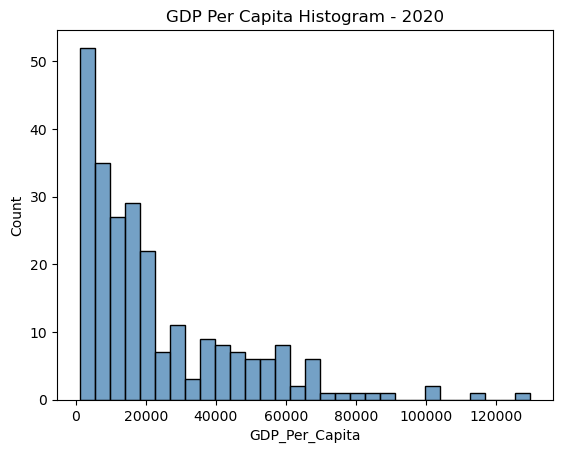

In [16]:
sns.histplot(data=gdp_df[gdp_df['Year'] == 2020],
             x='GDP_Per_Capita',
             bins=30,
             color='steelblue',
             edgecolor='black')
plt.title('GDP Per Capita Histogram - 2020')

### Density plot for 2020

Text(0.5, 1.0, 'GDP Per Capita Density - 2020')

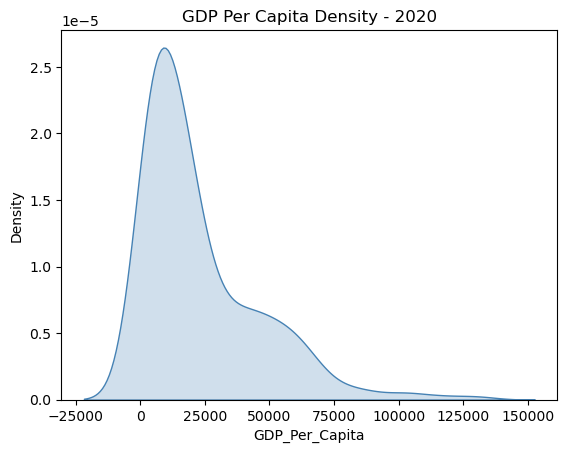

In [17]:
sns.kdeplot(data=gdp_df[gdp_df['Year'] == 2020],
            x='GDP_Per_Capita',
            fill=True,
            color='steelblue')
plt.title('GDP Per Capita Density - 2020')

### Boxplot for 2020

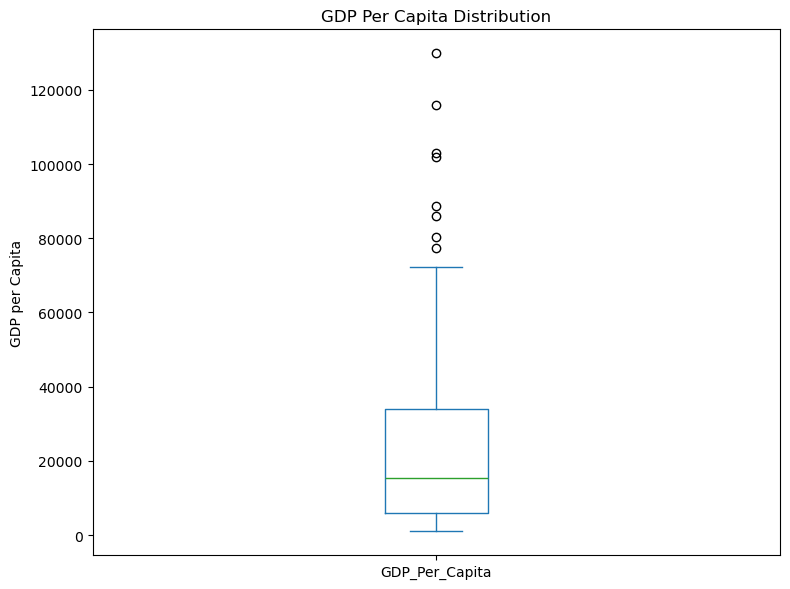

In [18]:
gdp_df[gdp_df['Year'] == 2020]['GDP_Per_Capita'].plot(kind = 'box', title = 'GDP Per Capita Distribution', figsize = (8,6))
plt.ylabel('GDP per Capita')
plt.tight_layout()
plt.show()

### Violin plot for 2020

Text(0.5, 1.0, 'GDP Per Capita Violin Plot - 2020')

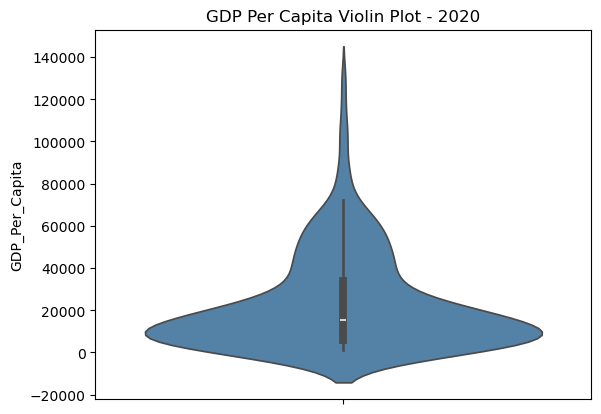

In [19]:
sns.violinplot(data=gdp_df[gdp_df['Year'] == 2020],
               y='GDP_Per_Capita',
               color='steelblue')
plt.title('GDP Per Capita Violin Plot - 2020')

## - What do you notice when you look at these plots? How do the plots compare, and what information can you get out of one type that you can't necessarily get out of the others?

### ASW: These plots show the big difference in GDP between countries; most of the countries are concentrated in the lower GDP numbers, and a few are in the high GDP numbers

## - What is the median GDP per Capita value in 2020?

In [20]:
median_gdp = gdp_df[gdp_df['Year'] == 2020]['GDP_Per_Capita'].median()
median_gdp

np.float64(15399.308958012449)

## - Subsett the data to just these 4 years into a new DataFrame named gdp_decades - 1990, 2000, 2010, 2020

In [21]:
gdp_decades = gdp_df[gdp_df['Year'].isin([1990, 2000, 2010, 2020])]
gdp_decades

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
13,Afghanistan,2010,2848.586061
23,Afghanistan,2000,1617.826475
28,Africa Eastern and Southern,2020,3978.931395
38,Africa Eastern and Southern,2010,3976.010989
...,...,...,...
8429,Zambia,1990,2425.111287
8434,Zimbabwe,2020,4527.719881
8444,Zimbabwe,2010,3885.393785
8454,Zimbabwe,2000,6170.333908


## - GDP_decades plots

### Boxplot 1990 - 2000 - 2010 - 2020

Text(0.5, 1.0, 'GDP Per Capita Boxplot by Decade')

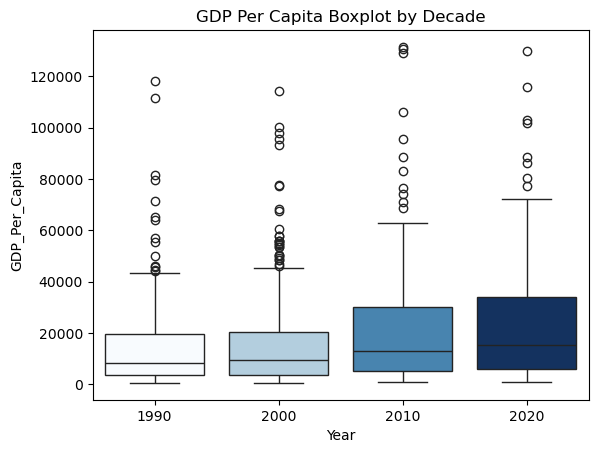

In [22]:
sns.boxplot(data=gdp_decades,
            x='Year',
            y='GDP_Per_Capita',
            hue='Year',
            legend=False,
            palette='Blues')
plt.title('GDP Per Capita Boxplot by Decade')

### Barplot 1990 - 2000 - 2010 - 2020

Text(0.5, 1.0, 'GDP Per Capita Barplot by Decade')

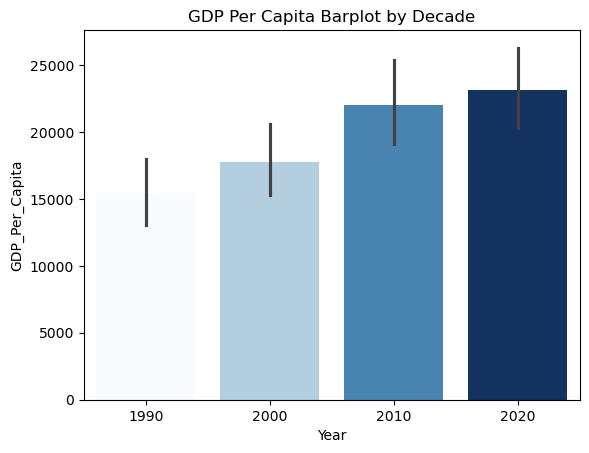

In [23]:
sns.barplot(data=gdp_decades,
            x='Year',
            y='GDP_Per_Capita',
            hue='Year',
            legend=False,
            palette='Blues')
plt.title('GDP Per Capita Barplot by Decade')

### Scatterplot 1990 - 2000 - 2010 - 2020

Text(0.5, 1.0, 'GDP Per Capita Scatterplot by Decade')

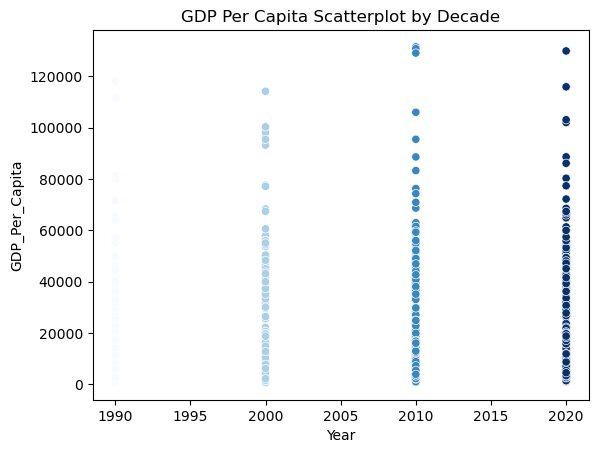

In [24]:
sns.scatterplot(data=gdp_decades,
                x='Year',
                y='GDP_Per_Capita',
                hue='Year',
                legend=False,
                palette='Blues')
plt.title('GDP Per Capita Scatterplot by Decade')

### Scatterplot with a trend line overlaid 1990 - 2000 - 2010 - 2020

Text(0.5, 1.0, 'GDP Per Capita Scatterplot with Trend Line by Decade')

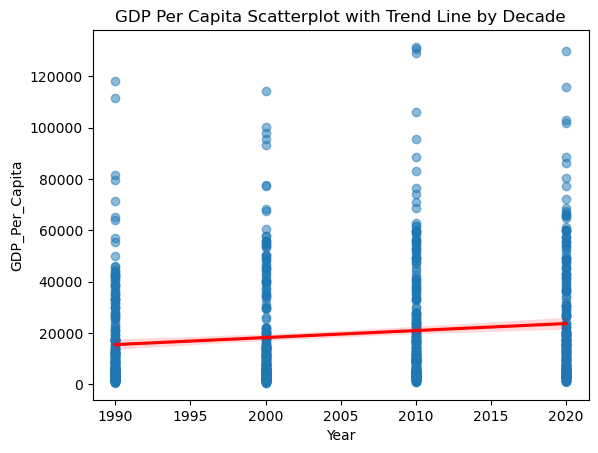

In [25]:
sns.regplot(data=gdp_decades,
            x='Year',
            y='GDP_Per_Capita',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'})
plt.title('GDP Per Capita Scatterplot with Trend Line by Decade')

## - What has happened to GDP values over time and the relative strengths and weaknesses of each type of plot

### The median has increased over time, but in my opinion, the best graphs that show a reliable data representation are the boxplot and the scatterplot with a trend line, because they show where the biggest change is.
### The interquartiles increased over time, and the increase in scatterplot length can be appreciated in the size of the vertical distribution. 

## - Which country was the first to have a GDP per capita greater than $100,000?

In [26]:
gdp_100k = gdp_df[gdp_df['GDP_Per_Capita'] > 100000]
first_country = gdp_100k.loc[gdp_100k['Year'].idxmin()]
first_country

Country           Brunei Darussalam
Year                           1990
GDP_Per_Capita         118163.68337
Name: 1037, dtype: object

## - Which country had the highest GDP per capita in 2020

In [27]:
gdp_2020 = gdp_df[gdp_df['Year'] == 2020]
highest_gdp_2020 = gdp_2020.loc[gdp_2020['GDP_Per_Capita'].idxmax()]
highest_gdp_2020

Country              Luxembourg
Year                       2020
GDP_Per_Capita    129865.629988
Name: 4629, dtype: object

## - Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

Text(0.5, 1.0, 'GDP Per Capita Over Time - Luxembourg')

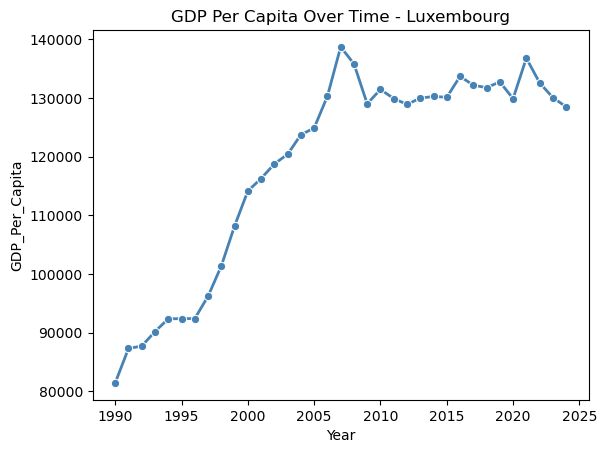

In [28]:
gdp_2020 = gdp_df[gdp_df['Year'] == 2020]
top_country = gdp_2020.loc[gdp_2020['GDP_Per_Capita'].idxmax(), 'Country']
country_df = gdp_df[gdp_df['Country'] == top_country]
sns.lineplot(data=country_df,
             x='Year',
             y='GDP_Per_Capita',
             color='steelblue',
             linewidth=2,
             marker='o')
plt.title(f'GDP Per Capita Over Time - {top_country}')

## - Which country had the lowest GDP per capita in 2020?

Text(0.5, 1.0, 'GDP Per Capita Over Time - Burundi')

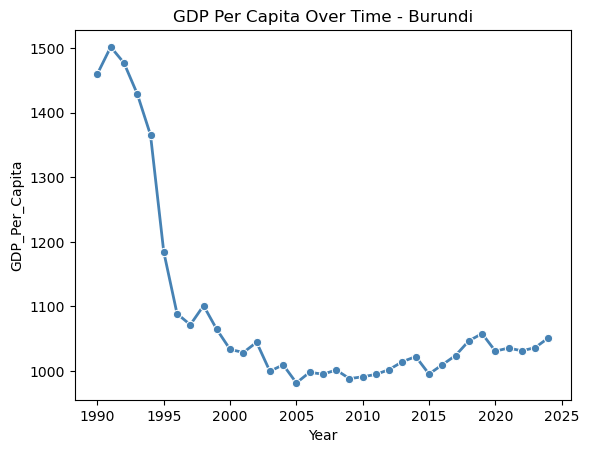

In [29]:
gdp_2020 = gdp_df[gdp_df['Year'] == 2020]
lowes_country = gdp_2020.loc[gdp_2020['GDP_Per_Capita'].idxmin(), 'Country']
country_df = gdp_df[gdp_df['Country'] == lowes_country]
sns.lineplot(data=country_df,
             x='Year',
             y='GDP_Per_Capita',
             color='steelblue',
             linewidth=2,
             marker='o')
plt.title(f'GDP Per Capita Over Time - {lowes_country}')

## - Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?

In [30]:
gdp_1990 = gdp_df.loc[gdp_df['Year'] == 1990, ['Country', 'GDP_Per_Capita']]
gdp_2020 = gdp_df.loc[gdp_df['Year'] == 2020, ['Country', 'GDP_Per_Capita']]
comparison = gdp_1990.merge(
    gdp_2020,
    on='Country',
    suffixes=('_1990', '_2020'),
    how='inner'
)
comparison['gdp_change'] = (
    comparison['GDP_Per_Capita_2020']
    - comparison['GDP_Per_Capita_1990']
)
comparison['pct_change'] = (
    comparison['gdp_change']
    / comparison['GDP_Per_Capita_1990']) * 100
went_up = (comparison['gdp_change'] > 0).sum()
went_down  = (comparison['gdp_change'] < 0).sum()
total    = len(comparison)

print(f"went_up : {went_up} of {total} countries")
print(f"went_down  : {went_down} of {total} countries")
declined = comparison[comparison['gdp_change'] < 0].sort_values('pct_change')

print(declined[['Country', 'GDP_Per_Capita_1990',
               'GDP_Per_Capita_2020', 'pct_change']])

went_up : 209 of 233 countries
went_down  : 24 of 233 countries
                                      Country  GDP_Per_Capita_1990  \
152                                     Nauru         30123.366206   
124                                     Libya         18126.586961   
45              Congo, Democratic Republic of          2403.970250   
222                      United Arab Emirates        111377.046890   
28                          Brunei Darussalam        118163.683370   
31                                    Burundi          1460.276459   
46                         Congo, Republic of          8699.526839   
232                                  Zimbabwe          6082.842451   
221                                   Ukraine         22815.798828   
38                   Central African Republic          1481.252551   
74                                      Gabon         23884.810700   
131                                Madagascar          1968.272398   
208                      S

### This is not true!

## - Read and check the internet_use dataframe

In [31]:
int_use = pd.read_csv('../data/internet_use.csv', nrows = 6083)

In [32]:
int_use.head(2)

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.6,1
1,Afghanistan,2018,16.8,2


In [33]:
int_use.tail(2)

,Country or Area,Year,Value,Value Footnotes
6081,Zimbabwe,1994,0.001739,NaN
6082,Zimbabwe,1990,0.000000,NaN


## - check the datatypes of the columns

In [34]:
int_use.info

<bound method DataFrame.info of      Country or Area  Year      Value Value Footnotes
0        Afghanistan  2019  17.600000               1
1        Afghanistan  2018  16.800000               2
2        Afghanistan  2017  13.500000               3
3        Afghanistan  2016  11.000000               4
4        Afghanistan  2015   8.260000               4
...              ...   ...        ...             ...
6078        Zimbabwe  1997   0.033080             NaN
6079        Zimbabwe  1996   0.016790             NaN
6080        Zimbabwe  1995   0.007684             NaN
6081        Zimbabwe  1994   0.001739             NaN
6082        Zimbabwe  1990   0.000000             NaN

[6083 rows x 4 columns]>

## - Drop the 'Value Footnotes' column and rename the columns to: Country, Year and Internet_Users_Pct

In [35]:
int_use = int_use.drop(columns = ['Value Footnotes'])

In [36]:
int_use

,Country or Area,Year,Value
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


In [37]:
int_use = int_use.rename(columns = {'Country or Area' : 'Country', 'Year': 'Year', 'Value' : 'Internet_Users_Pct'})

In [38]:
int_use

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


## - Look at the number of observations in this dataset per year. What do you notice?

In [39]:
int_use.info()

<class 'pandas.DataFrame'>
RangeIndex: 6083 entries, 0 to 6082
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             6083 non-null   str    
 1   Year                6083 non-null   int64  
 2   Internet_Users_Pct  6083 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 142.7 KB


### ASW: There are no nulls in the dataset

## - What is the first year to have a non-zero internet users percentage value?

In [40]:
first_year_global = int_use.loc[int_use['Internet_Users_Pct'] > 0, 'Year'].min()
print(f"First Year with internet > 0: {first_year_global}")

First Year with internet > 0: 1990


## - How does the distribution of internet users percent differ for 2000 and 2014?

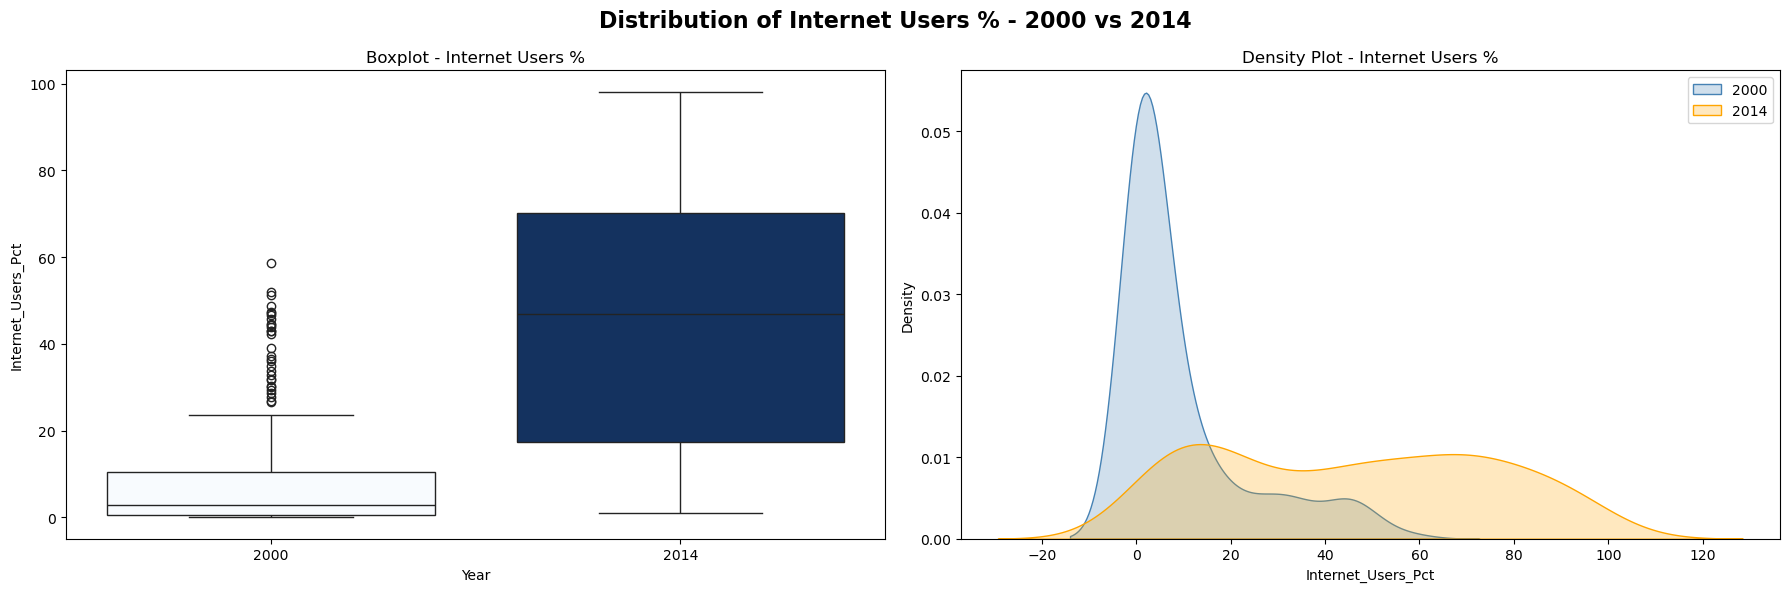

In [41]:
internet_filtered = int_use[int_use['Year'].isin([2000, 2014])]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=internet_filtered,
            x='Year',
            y='Internet_Users_Pct',
            hue='Year',
            legend=False,
            palette='Blues',
            ax=axes[0])
axes[0].set_title('Boxplot - Internet Users %')
sns.kdeplot(data=int_use[int_use['Year'] == 2000],
            x='Internet_Users_Pct',
            fill=True,
            label='2000',
            color='steelblue',
            ax=axes[1])
sns.kdeplot(data=int_use[int_use['Year'] == 2014],
            x='Internet_Users_Pct',
            fill=True,
            label='2014',
            color='orange',
            ax=axes[1])
axes[1].legend()
axes[1].set_title('Density Plot - Internet Users %')
plt.suptitle('Distribution of Internet Users % - 2000 vs 2014', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
median_internet_2000 = int_use[int_use['Year'] == 2000]['Internet_Users_Pct'].median()
print('median internet 2000 =', median_internet_2000)
median_internet_2014 = int_use[int_use['Year'] == 2014]['Internet_Users_Pct'].median()
print('median internet 2014 =', median_internet_2014)

median internet 2000 = 2.88668
median internet 2014 = 46.818


### ASW: the internet distribution is completely different between the year 2000 and 2014, the internet_Users_Pct went from 2.89 in 2000 up to 46.82 in 2014

## - For how many countries was the percentage of internet users below 5% in 2014?

In [43]:
below_5_2014 = int_use[(int_use['Year'] == 2014) & 
                            (int_use['Internet_Users_Pct'] < 5)]
below_5_2014

,Country,Year,Internet_Users_Pct
873,Burundi,2014,1.04239
1033,Central African Republic,2014,2.70000
1061,Chad,2014,2.90000
1517,Democratic Republic of the Congo,2014,3.00000
1782,Eritrea,2014,0.99000
2451,Guinea-Bissau,2014,3.32000
3364,Madagascar,2014,3.70000
4073,Niger,2014,1.24868
5055,Somalia,2014,1.63000
5116,South Sudan,2014,2.60000


## - Merge the two DataFrames to one. Do this in a way that keeps **all rows** from each of the two DataFrames. Call the new DataFrame `gdp_and_internet_use`. Look at the first and last few rows to confirm that it merged correctly.

In [44]:
gdp_and_internet_use = gdp_df.merge(int_use, 
                                     on=['Country', 'Year'], 
                                     how='outer')

In [45]:
gdp_and_internet_use.head()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,Afghanistan,1990,NaN,0.000000
1,Afghanistan,2000,1617.826475,NaN
2,Afghanistan,2001,1454.110782,0.004723
3,Afghanistan,2002,1774.308743,0.004561
4,Afghanistan,2003,1815.928200,0.087891


In [46]:
gdp_and_internet_use.tail()

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
9775,Zimbabwe,2020,4527.719881,29.2986
9776,Zimbabwe,2021,4827.088694,32.4616
9777,Zimbabwe,2022,5036.761361,32.5615
9778,Zimbabwe,2023,5218.022665,NaN
9779,Zimbabwe,2024,5215.253011,NaN


## - Find the three countries with the highest internet users percentage in 2014

In [47]:
top3_countries = (gdp_and_internet_use[gdp_and_internet_use['Year'] == 2014]
                  .nlargest(3, 'Internet_Users_Pct')['Country']
                  .values)
print(f"Top 3 countries with highest internet users in 2014:{top3_countries}")

Top 3 countries with highest internet users in 2014:<StringArray>
['Iceland', 'Falkland (Malvinas) Islands', 'Bermuda']
Length: 3, dtype: str


## - Use a seaborn FacetGrid to compare how the GDP per capita has changed over time for these three countries

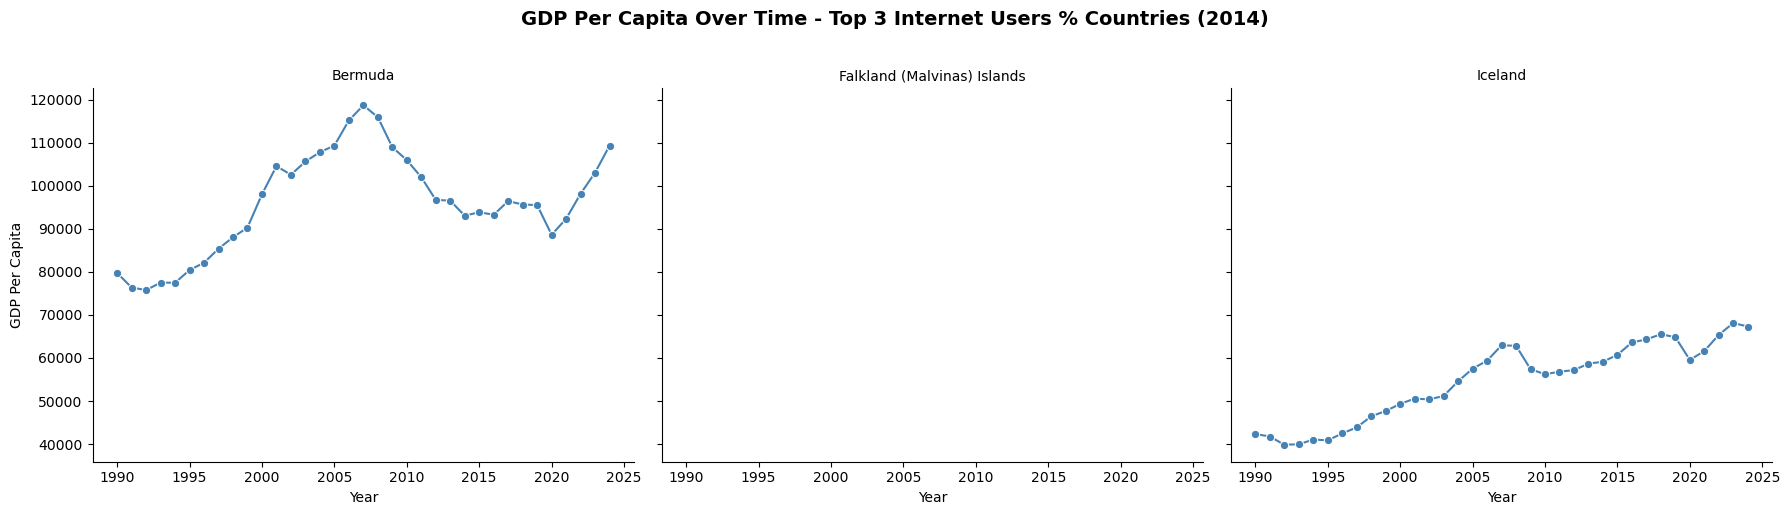

In [48]:
top3_df = gdp_and_internet_use[gdp_and_internet_use['Country'].isin(top3_countries)]
g = sns.FacetGrid(data=top3_df, 
                  col='Country', 
                  height=5, 
                  aspect=1.2)
g.map(sns.lineplot, 'Year', 'GDP_Per_Capita', color='steelblue', marker='o')
g.set_axis_labels('Year', 'GDP Per Capita')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('GDP Per Capita Over Time - Top 3 Internet Users % Countries (2014)', 
                   fontsize=14, 
                   fontweight='bold',
                   y=1.02)
plt.tight_layout()
plt.show()

## - Subset `gdp_and_internet_use` to just the year 2014. Save this as a new dataframe named `gdp_and_internet_use_2014`

In [49]:
gdp_and_internet_use_2014 = gdp_and_internet_use[gdp_and_internet_use['Year'] == 2014]
gdp_and_internet_use_2014

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
15,Afghanistan,2014,3017.942544,7.0000
49,Africa Eastern and Southern,2014,4185.238411,NaN
84,Africa Western and Central,2014,6174.703316,NaN
119,Albania,2014,12718.284760,54.3000
154,Algeria,2014,15073.762940,29.5000
...,...,...,...,...
9638,West Bank and Gaza,2014,5990.426615,NaN
9673,World,2014,17492.498902,NaN
9703,Yemen,2014,NaN,22.5500
9734,Zambia,2014,3585.577485,6.5000


## - Create a plot which compares Internet Users Percentage and GDP per Capita for the year 2014. What do you notice from this plot? If you see any unusual points, investigate them.

Text(0.5, 1.0, 'Internet Users % vs GDP Per Capita - 2014')

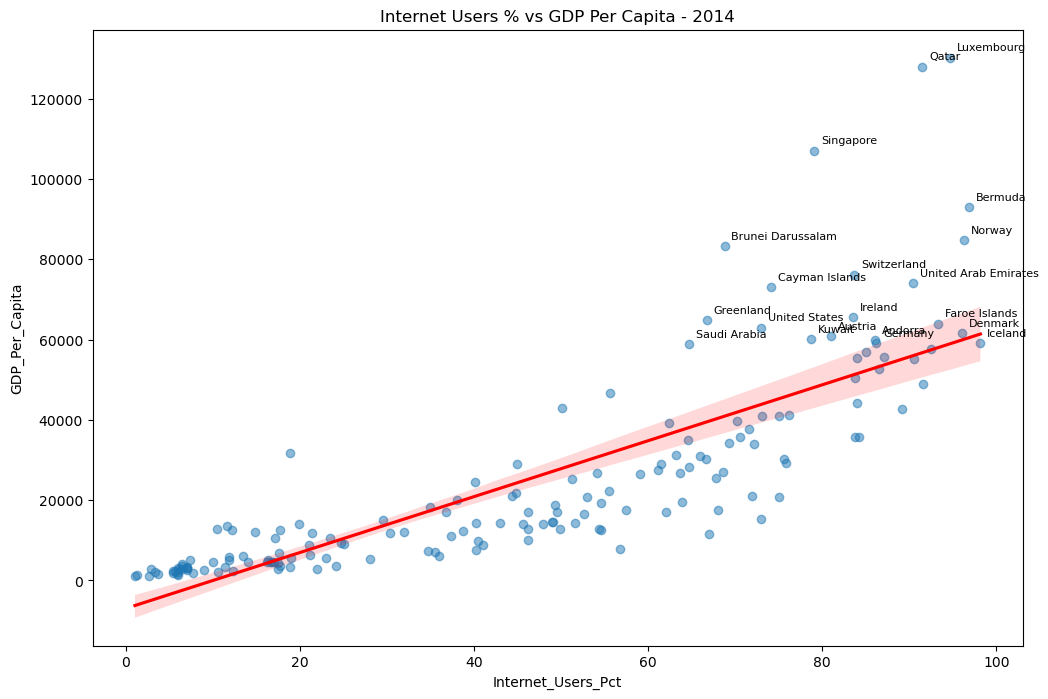

In [88]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.regplot(data=gdp_and_internet_use_2014,
            x='Internet_Users_Pct',
            y='GDP_Per_Capita',
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red'},
            ax=ax)
threshold = gdp_and_internet_use_2014['GDP_Per_Capita'].quantile(0.90)
outliers = gdp_and_internet_use_2014[gdp_and_internet_use_2014['GDP_Per_Capita'] > threshold]
for _, row in outliers.iterrows():
    ax.annotate(row['Country'],
                xy=(row['Internet_Users_Pct'], row['GDP_Per_Capita']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8)
plt.title('Internet Users % vs GDP Per Capita - 2014')

In [51]:
gdp_and_internet_use_2014['GDP_group'] = pd.qcut(gdp_and_internet_use_2014['GDP_Per_Capita'],
                                                   q=3,
                                                   labels=['Low', 'Medium', 'High'])
print(gdp_and_internet_use_2014[['Country', 'GDP_Per_Capita', 'GDP_group']].head(10))
print("\nValue counts per group:")
print(gdp_and_internet_use_2014['GDP_group'].value_counts())

                         Country  GDP_Per_Capita GDP_group
15                   Afghanistan     3017.942544       Low
49   Africa Eastern and Southern     4185.238411       Low
84    Africa Western and Central     6174.703316       Low
119                      Albania    12718.284760    Medium
154                      Algeria    15073.762940    Medium
190                      Andorra    59929.244467      High
225                       Angola    11721.664416    Medium
252                     Anguilla             NaN       NaN
279          Antigua and Barbuda    25557.524912      High
314                   Arab World    16145.889846    Medium

Value counts per group:
GDP_group
Low       83
Medium    82
High      82
Name: count, dtype: int64


## - How does the median internet users percentage compare for the three gdp groups?

In [52]:
median_internet_by_group = gdp_and_internet_use_2014.groupby('GDP_group')['Internet_Users_Pct'].median()

print("Median Internet Users % by GDP Group:")
print(median_internet_by_group)

Median Internet Users % by GDP Group:
GDP_group
Low       11.80000
Medium    45.19685
High      75.33550
Name: Internet_Users_Pct, dtype: float64


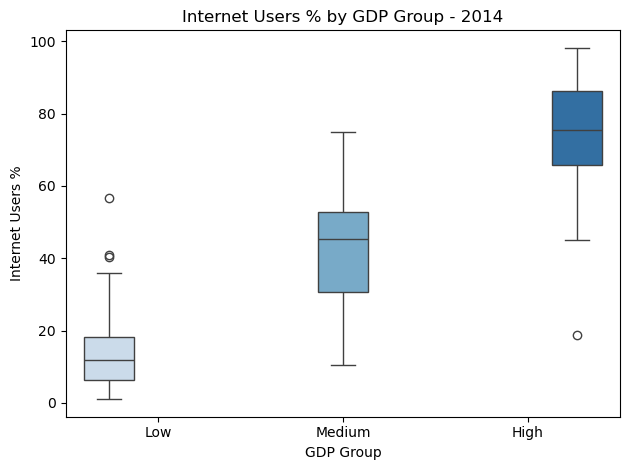

In [53]:
sns.boxplot(data=gdp_and_internet_use_2014,
            x='GDP_group',
            y='Internet_Users_Pct',
            hue='GDP_group',
            legend=False,
            palette='Blues',
            order=['Low', 'Medium', 'High'])

plt.title('Internet Users % by GDP Group - 2014')
plt.xlabel('GDP Group')
plt.ylabel('Internet Users %')
plt.tight_layout()
plt.show()

## - Download another data set from the UN data to merge with your data and explore

In [116]:
new_df = pd.read_csv('../data/UNdata_Export_20260610_000151929.csv')

In [117]:
new_df.head(2)

,Reference Area,Time Period,Sex,Age group,Units of measurement,Observation Value
0,Afghanistan,2014,All genders,Not applicable,Number,6217756.0
1,Afghanistan,2014,Female,Not applicable,Number,2484471.0


In [118]:
new_df.tail(2)

,Reference Area,Time Period,Sex,Age group,Units of measurement,Observation Value
14141,Zimbabwe,1975,All genders,Not applicable,Number,862736.0
14142,Zimbabwe,1975,Female,Not applicable,Number,395114.0


In [119]:
new_df = new_df.drop(columns = ['Age group'])

In [120]:
new_df = new_df.drop(columns = ['Units of measurement'])

In [121]:
new_df = new_df[new_df['Sex'] == 'All genders']

In [122]:
new_df

,Reference Area,Time Period,Sex,Observation Value
0,Afghanistan,2014,All genders,6217756.0
3,Afghanistan,2013,All genders,5986268.0
4,Afghanistan,2012,All genders,5767543.0
7,Afghanistan,2011,All genders,5291624.0
9,Afghanistan,2010,All genders,5279326.0
...,...,...,...,...
14133,Zimbabwe,1979,All genders,831879.0
14136,Zimbabwe,1978,All genders,826857.0
14137,Zimbabwe,1977,All genders,890460.0
14140,Zimbabwe,1976,All genders,882375.0


In [123]:
new_df.info

<bound method DataFrame.info of       Reference Area  Time Period          Sex  Observation Value
0        Afghanistan         2014  All genders          6217756.0
3        Afghanistan         2013  All genders          5986268.0
4        Afghanistan         2012  All genders          5767543.0
7        Afghanistan         2011  All genders          5291624.0
9        Afghanistan         2010  All genders          5279326.0
...              ...          ...          ...                ...
14133       Zimbabwe         1979  All genders           831879.0
14136       Zimbabwe         1978  All genders           826857.0
14137       Zimbabwe         1977  All genders           890460.0
14140       Zimbabwe         1976  All genders           882375.0
14141       Zimbabwe         1975  All genders           862736.0

[7340 rows x 4 columns]>

In [124]:
new_df = new_df.rename(columns = {'Reference Area' : 'Country', 'Time Period': 'Year', 'Observation Value' : 'prim_Count'})

In [125]:
new_df

,Country,Year,Sex,prim_Count
0,Afghanistan,2014,All genders,6217756.0
3,Afghanistan,2013,All genders,5986268.0
4,Afghanistan,2012,All genders,5767543.0
7,Afghanistan,2011,All genders,5291624.0
9,Afghanistan,2010,All genders,5279326.0
...,...,...,...,...
14133,Zimbabwe,1979,All genders,831879.0
14136,Zimbabwe,1978,All genders,826857.0
14137,Zimbabwe,1977,All genders,890460.0
14140,Zimbabwe,1976,All genders,882375.0


In [126]:
gdp_int_and_educ = gdp_and_internet_use.merge(new_df, 
                                     on=['Country', 'Year'], 
                                     how='outer')

In [128]:
gdp_int_and_educ['Country'] = gdp_int_and_educ['Country'].replace({
    'United States': 'USA',
    'United States of America': 'USA'
})

In [129]:
gdp_int_and_educ

,Country,Year,GDP_Per_Capita,Internet_Users_Pct,Sex,prim_Count
0,Afghanistan,1975,NaN,NaN,All genders,692342.0
1,Afghanistan,1976,NaN,NaN,All genders,729667.0
2,Afghanistan,1977,NaN,NaN,All genders,764175.0
3,Afghanistan,1978,NaN,NaN,All genders,810657.0
4,Afghanistan,1980,NaN,NaN,All genders,959583.0
...,...,...,...,...,...,...
13437,Zimbabwe,2020,4527.719881,29.2986,NaN,NaN
13438,Zimbabwe,2021,4827.088694,32.4616,NaN,NaN
13439,Zimbabwe,2022,5036.761361,32.5615,NaN,NaN
13440,Zimbabwe,2023,5218.022665,NaN,NaN,NaN


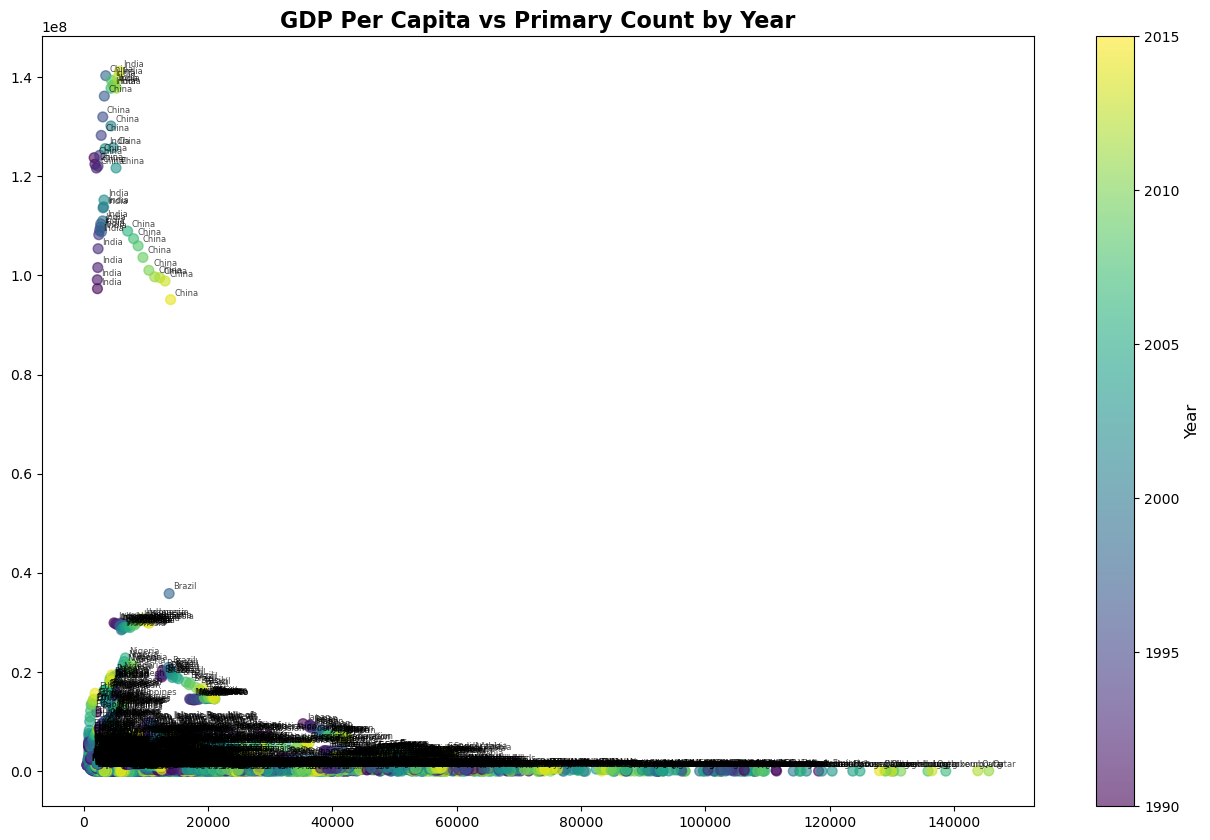

In [132]:
plot_df = gdp_int_and_educ[
    gdp_int_and_educ['prim_Count'].notna() & 
    gdp_int_and_educ['GDP_Per_Capita'].notna()]
fig, ax = plt.subplots(figsize=(16, 10))
scatter = ax.scatter(data=plot_df,
                     x='GDP_Per_Capita',
                     y='prim_Count',
                     c='Year',
                     cmap='viridis',
                     alpha=0.6,
                     s=50)
for _, row in plot_df.iterrows():
    ax.annotate(row['Country'],
                xy=(row['GDP_Per_Capita'], row['prim_Count']),
                xytext=(3, 3),
                textcoords='offset points',
                fontsize=6,
                alpha=0.7)
colorbar = plt.colorbar(scatter)
colorbar.set_label('Year', fontsize=12)

plt.title('GDP Per Capita vs Primary Count by Year', fontsize=16, fontweight='bold')
plt.show()

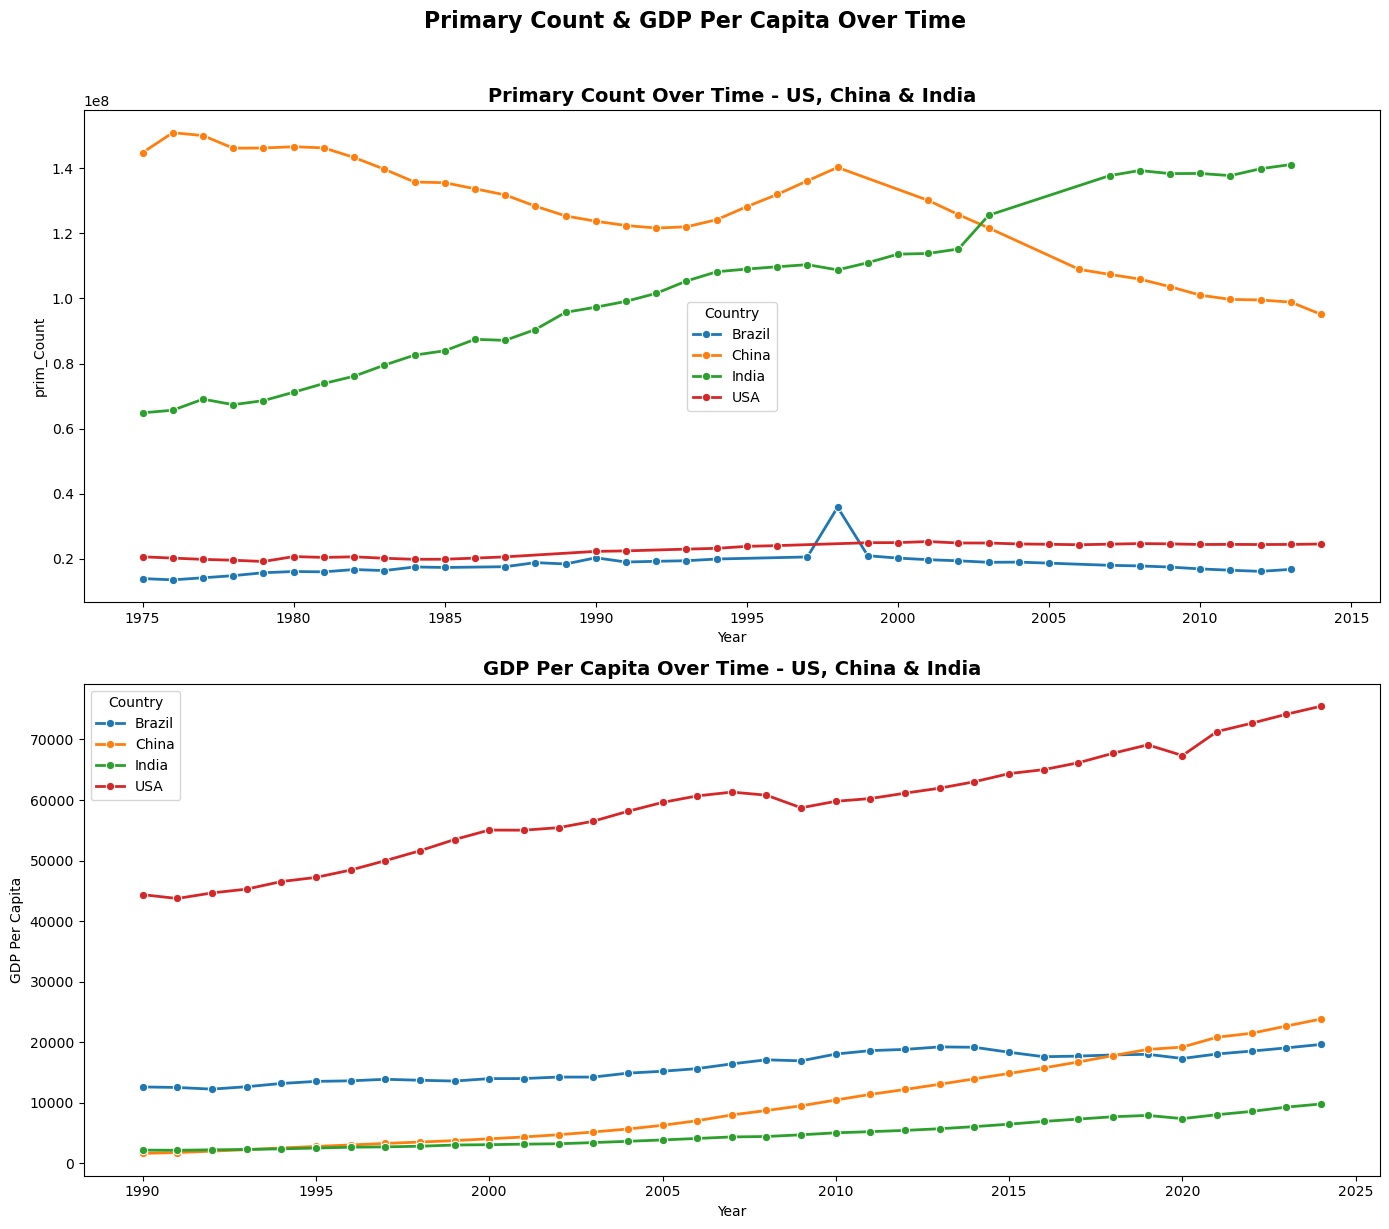

In [135]:
countries = ['USA', 'China', 'India', 'Brazil']
plot_df_count = gdp_int_and_educ[
    gdp_int_and_educ['Country'].isin(countries) &
    gdp_int_and_educ['prim_Count'].notna()]
plot_df_gdp = gdp_int_and_educ[
    gdp_int_and_educ['Country'].isin(countries) &
    gdp_int_and_educ['GDP_Per_Capita'].notna()]
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
sns.lineplot(data=plot_df_count,
             x='Year',
             y='prim_Count',
             hue='Country',
             linewidth=2,
             marker='o',
             ax=axes[0])
axes[0].set_title('Primary Count Over Time - US, China & India', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('prim_Count')
axes[0].legend(title='Country')
sns.lineplot(data=plot_df_gdp,
             x='Year',
             y='GDP_Per_Capita',
             hue='Country',
             linewidth=2,
             marker='o',
             ax=axes[1])
axes[1].set_title('GDP Per Capita Over Time - US, China & India', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP Per Capita')
axes[1].legend(title='Country')
plt.suptitle('Primary Count & GDP Per Capita Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()